<a id="time_analysis"></a>
## Extended Time Analysis

This section provides comprehensive time-based analysis of article distribution patterns and trends.

### Contents:
* [Overall Time Distribution](#overall_time_enhanced)
* [Time Distribution by Publisher](#time_by_publisher)  
* [Time Distribution by Section](#time_by_section)
* [Average Article Length Over Time](#length_over_time)

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import plotly.graph_objects as go
import seaborn as sns
from datetime import datetime
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
from utils_without_openai import compare_histograms, line_time_plot, stacked_time_plot

In [16]:
df_articles = pd.read_pickle("../data/cleaned/cleaned_articles (2).pkl")
df_articles.head()

,title,publisher,date,section,body,length,letters_flag,country_flag,foreign_countries,us_mentions,source_file,publisher_raw,section_clean,section_category
0,A Well-Documented Childhood. A Very Private Life.,New York Times,2024-12-31,Section A; Column 0; National Desk; Pg. 16,Jimmy Carter's daughter had an extraordinary a...,1209,False,BOTH,"[Canada, Egypt, Mexico, Nicaragua, Washington ...","[Massachusetts, Rhode Island, US, Washington]",NYT/1.DOCX,The New York Times,section a; column 0; national desk; pg. 16,US/National
1,These were the big stories in arts and culture...,Other publisher,2024-12-31,WHAT TO KNOW,The arts in Dayton continued to thrive in 2024...,3345,False,BOTH,"[France, Japan, Paris (Capital), Sierra Leone,...","[America, California, Florida, Georgia, Massac...",Other publishers/Files (500) (1).DOCX,Dayton Daily News (Ohio),what to know,None
2,She Exalted The Beauty Of Dance,New York Times,2024-12-31,Section C; Column 0; The Arts/Cultural Desk; P...,She was The New Yorker's first dance critic. H...,1314,False,BOTH,[Male (Capital)],"[New York, North Carolina, US, United States]",NYT/1.DOCX,The New York Times,section c; column 0; the arts/cultural desk; p...,Arts/Culture
3,"Under a Highway in Rio, a Dance Style Charms a...",New York Times,2024-12-31,WORLD; americas,"Trucks, buses and cars rumbled overhead, drown...",1333,False,BOTH,"[Brazil, Lima (Capital)]","[New York, US, United States]",NYT/1.DOCX,The New York Times,world; americas,World/International
4,"Congressional pay, minimum wage stagnant for y...",Other publisher,2024-12-31,OPINION; Pg. A13,ABSTRACT\nMembers of Congress have not seen a ...,921,False,US_ONLY,[],"[America, Delaware, Maryland, New Jersey, New ...",Other publishers/Files (500) (1).DOCX,The Philadelphia Inquirer,opinion; pg. a13,Opinion/Editorial/Letters


In [17]:
print("Available columns:", df_articles.columns.tolist())

Available columns: ['title', 'publisher', 'date', 'section', 'body', 'length', 'letters_flag', 'country_flag', 'foreign_countries', 'us_mentions', 'source_file', 'publisher_raw', 'section_clean', 'section_category']


In [18]:
# Create word count from body text
def count_words_from_body(text):
    """Count words in the body text"""
    if pd.isna(text):
        return 0
    return len(str(text).split())

df_articles['word_count'] = df_articles['body'].apply(count_words_from_body)

# Get publisher counts
publisher_counts = df_articles['publisher'].value_counts()
print("\nPublisher distribution:")
for pub, count in publisher_counts.items():
    print(f"  {pub}: {count:,} articles")


Publisher distribution:
  New York Times: 25,586 articles
  Other publisher: 14,277 articles


In [19]:
df_articles['date'] = pd.to_datetime(df_articles['date'], errors='coerce')
df_articles['year'] = df_articles['date'].dt.year
df_articles['year_month'] = df_articles['date'].dt.to_period('M')

<a id="overall_time_enhanced"></a>
### Overall Time Distribution

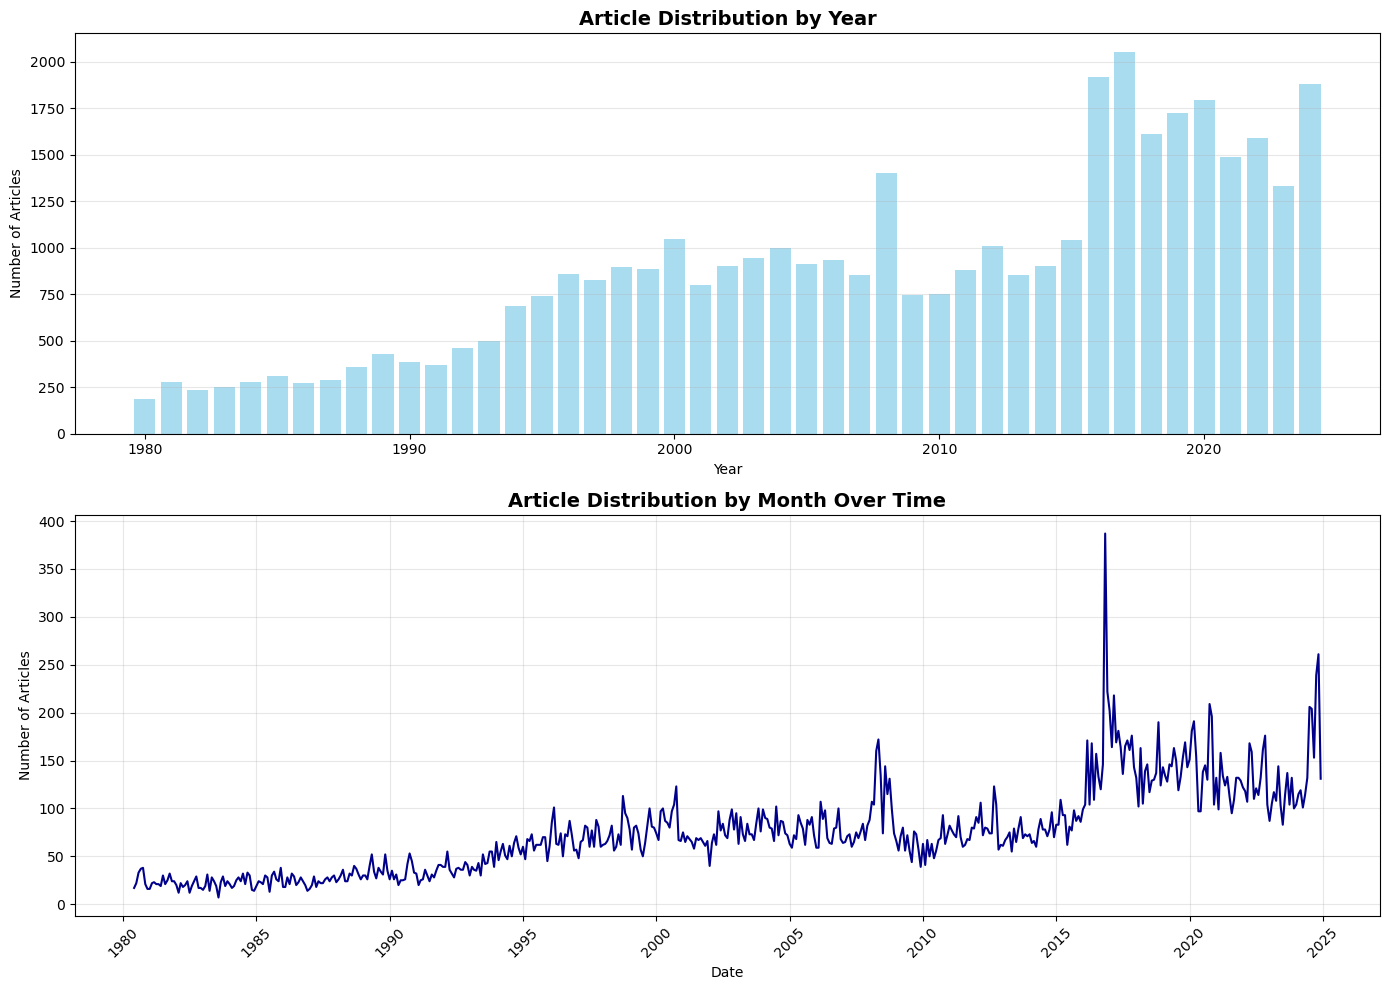

Total articles: 39,863
Date range: 1980-06-01 00:00:00 to 2024-12-31 00:00:00
Average articles per year: 885.8


In [20]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

yearly_counts = df_articles['year'].value_counts().sort_index()
ax1.bar(yearly_counts.index, yearly_counts.values, color='skyblue', alpha=0.7)
ax1.set_title('Article Distribution by Year', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Articles')
ax1.grid(axis='y', alpha=0.3)

monthly_counts = df_articles.groupby('year_month').size()
ax2.plot(monthly_counts.index.to_timestamp(), monthly_counts.values, color='darkblue', linewidth=1.5)
ax2.set_title('Article Distribution by Month Over Time', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Number of Articles')
ax2.grid(alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


monthly_counts = df_articles.groupby('year_month').size()
monthly_df = pd.DataFrame({
    'Date': monthly_counts.index.to_timestamp(),
    'Article_Count': monthly_counts.values
})

fig_interactive = go.Figure()

fig_interactive.add_trace(go.Scatter(
    x=monthly_df['Date'],
    y=monthly_df['Article_Count'],
    mode='lines+markers',
    name='Articles per Month',
    line=dict(color='darkblue', width=2),
    marker=dict(size=4),
    hovertemplate='<b>Date:</b> %{x|%Y-%m}<br>' +
                  '<b>Articles:</b> %{y}<br>' +
                  '<extra></extra>'
))

fig_interactive.update_layout(
    title='Interactive Article Distribution by Month Over Time',
    xaxis_title='Date',
    yaxis_title='Number of Articles',
    hovermode='x unified',
    showlegend=False,
    width=900,
    height=500,
    template='plotly_white'
)

fig_interactive.update_layout(
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1Y", step="year", stepmode="backward"),
                dict(count=5, label="5Y", step="year", stepmode="backward"),
                dict(count=10, label="10Y", step="year", stepmode="backward"),
                dict(step="all")
            ])
        ),
        rangeslider=dict(visible=True),
        type="date"
    )
)

fig_interactive.show()

print(f"Total articles: {len(df_articles):,}")
print(f"Date range: {df_articles['date'].min()} to {df_articles['date'].max()}")
print(f"Average articles per year: {len(df_articles) / len(yearly_counts):.1f}")

<a id="time_by_publisher"></a>
### Time Distribution by Publishe


------------------------------------------------------------
ARTICLE DISTRIBUTION BY PUBLISHER OVER TIME
------------------------------------------------------------


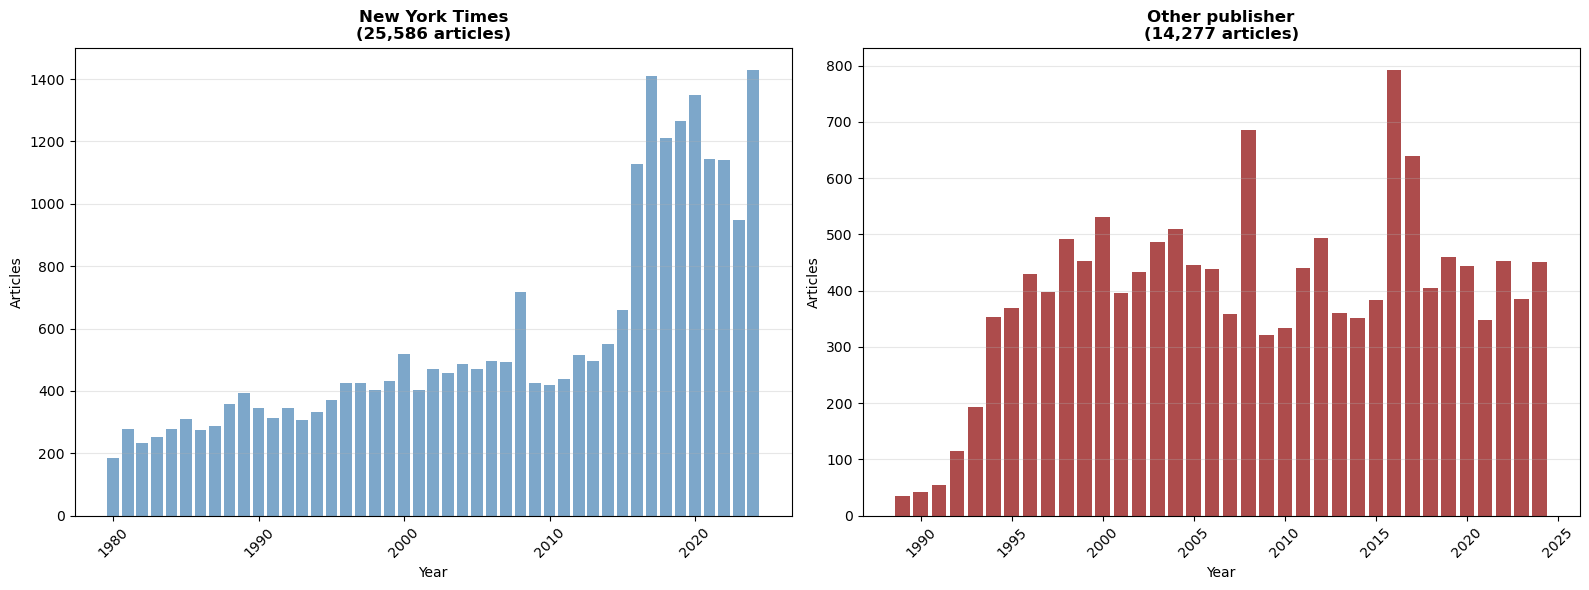

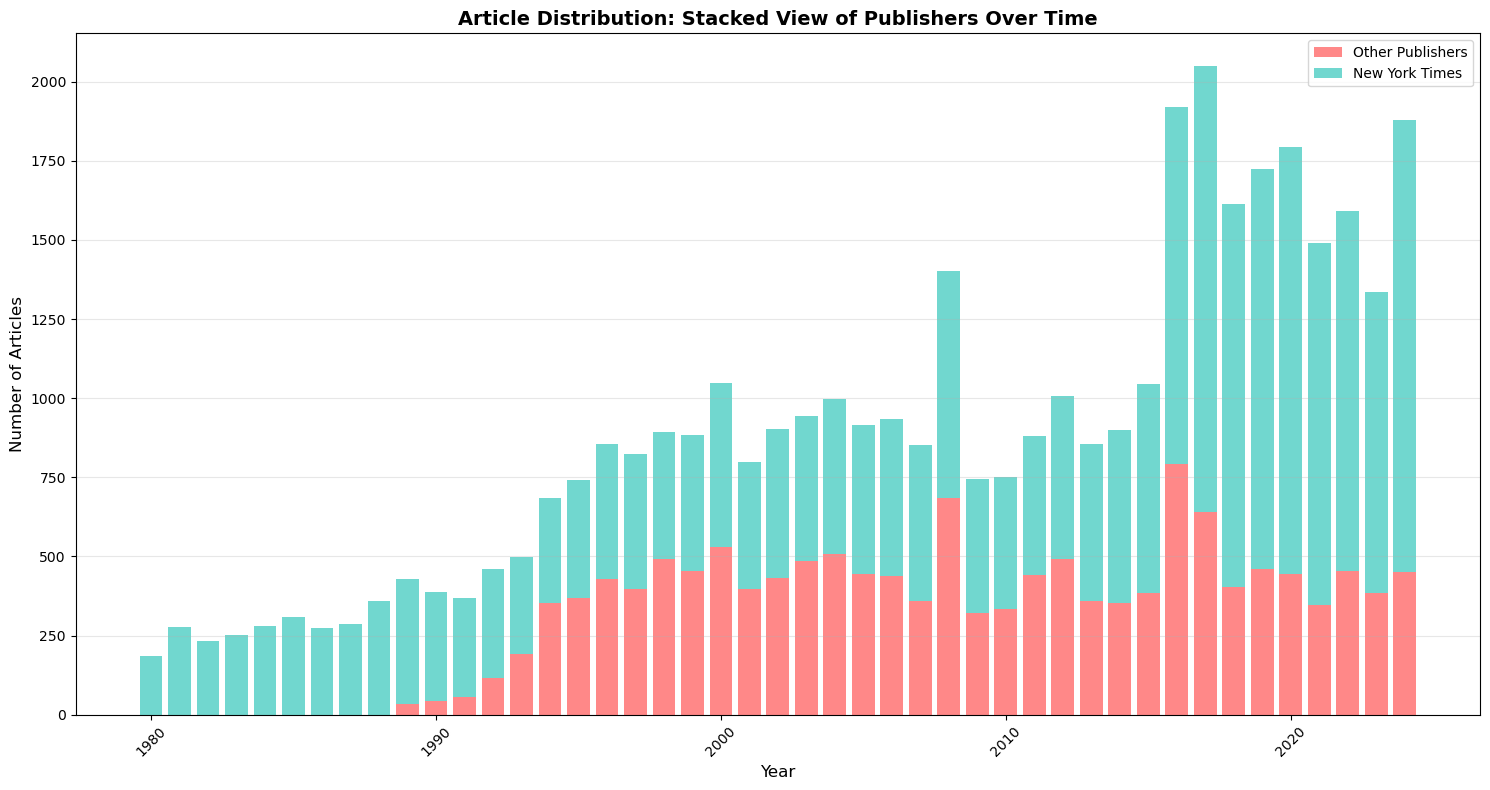

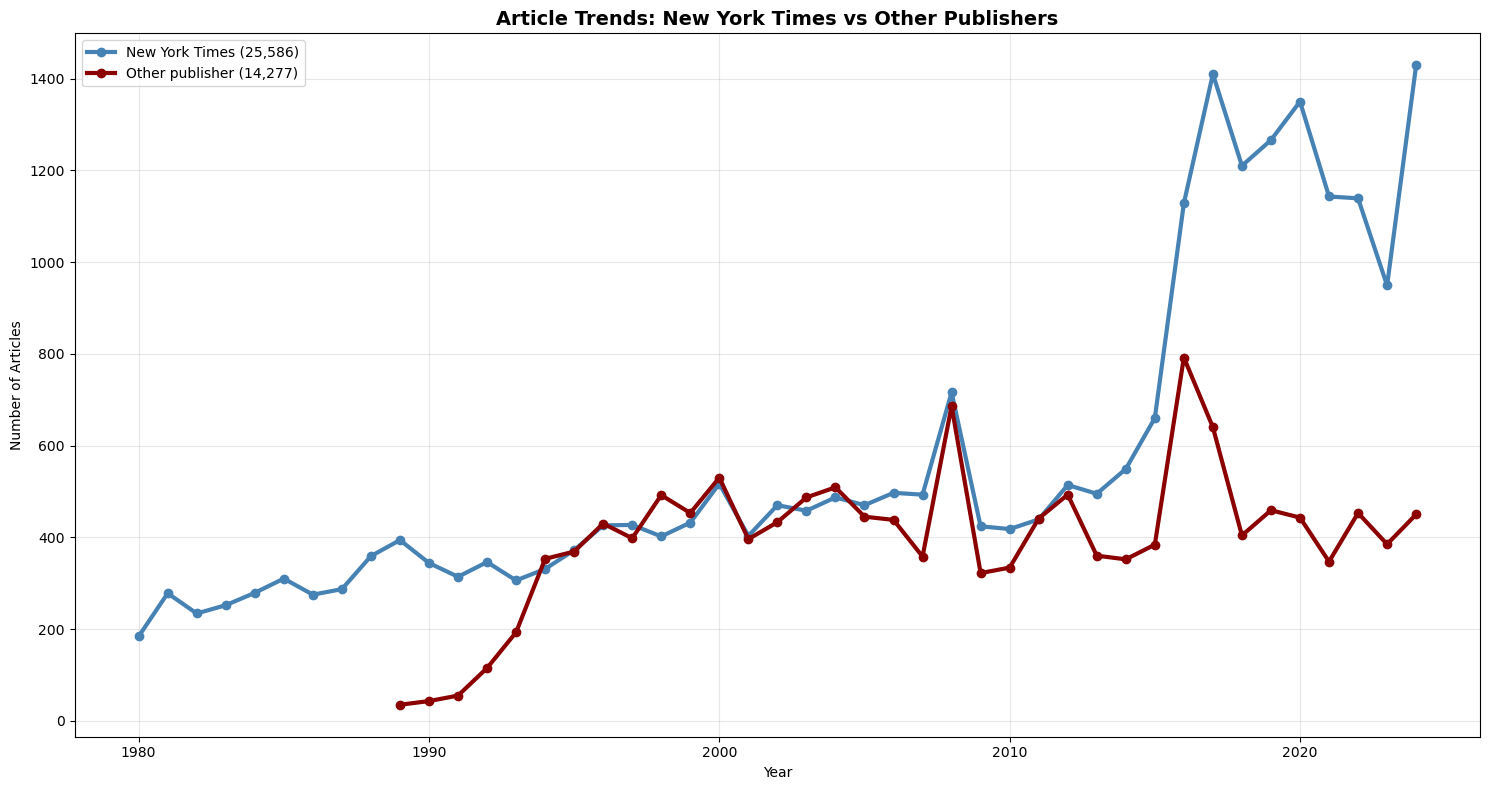

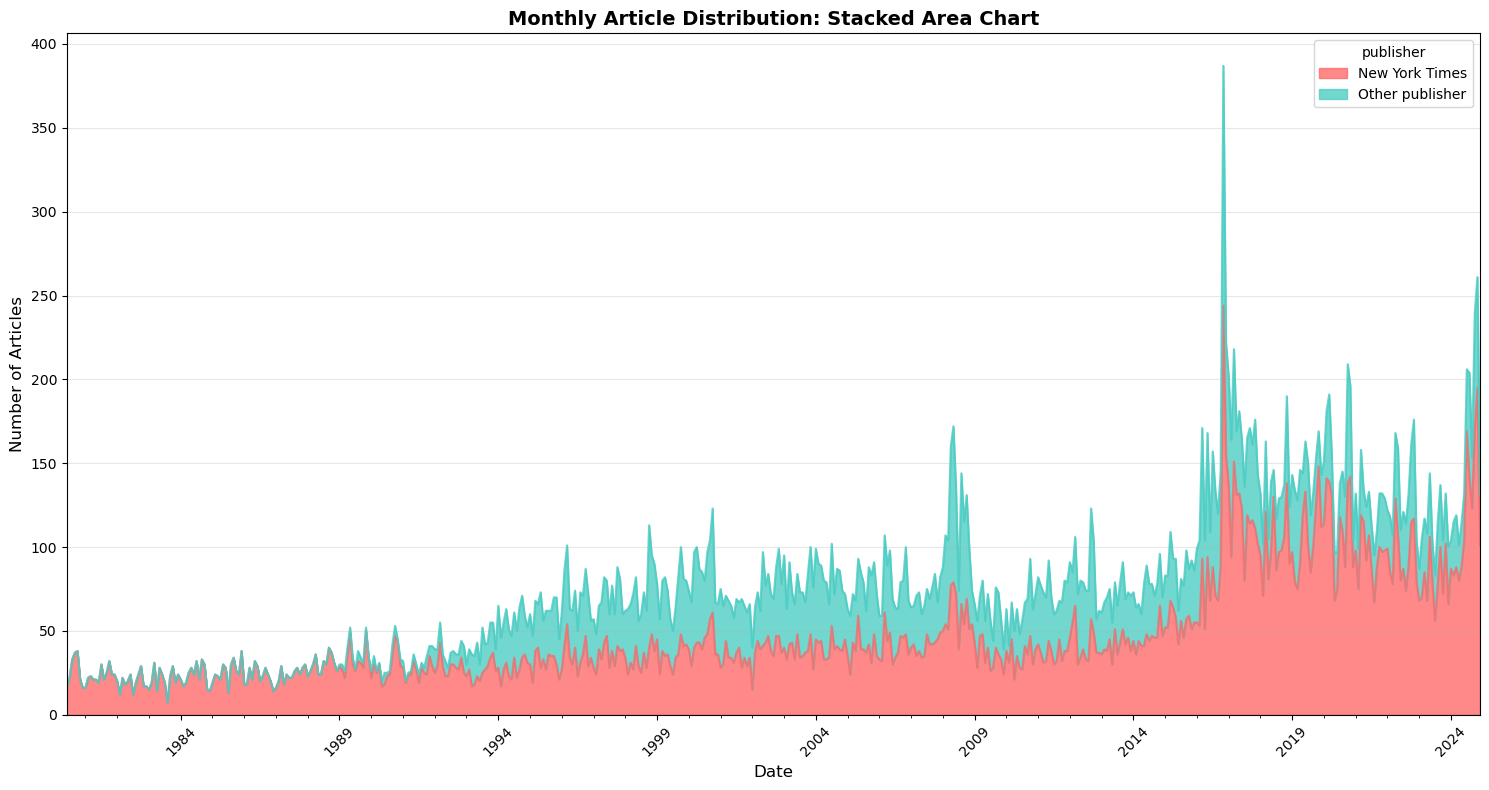

In [21]:
print(f"\n{'-'*60}")
print("ARTICLE DISTRIBUTION BY PUBLISHER OVER TIME")
print(f"{'-'*60}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['steelblue', 'darkred']
publishers = publisher_counts.index.tolist()

for i, publisher in enumerate(publishers):
    publisher_data = df_articles[df_articles['publisher'] == publisher]
    yearly_pub_counts = publisher_data['year'].value_counts().sort_index()
    
    axes[i].bar(yearly_pub_counts.index, yearly_pub_counts.values, 
               color=colors[i], alpha=0.7)
    axes[i].set_title(f'{publisher}\n({publisher_counts[publisher]:,} articles)', 
                     fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('Articles')
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(15, 8))

nyt_data = df_articles[df_articles['publisher'] == 'New York Times']
other_data = df_articles[df_articles['publisher'] == 'Other publisher']

nyt_yearly = nyt_data['year'].value_counts().sort_index()
other_yearly = other_data['year'].value_counts().sort_index()

all_years = sorted(set(nyt_yearly.index) | set(other_yearly.index))
nyt_counts = [nyt_yearly.get(year, 0) for year in all_years]
other_counts = [other_yearly.get(year, 0) for year in all_years]

width = 0.8
ax.bar(all_years, other_counts, width, label='Other Publishers', 
       color='#FF6B6B', alpha=0.8) 
ax.bar(all_years, nyt_counts, width, bottom=other_counts, 
       label='New York Times', color='#4ECDC4', alpha=0.8) 

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.set_title('Article Distribution: Stacked View of Publishers Over Time', 
             fontsize=14, fontweight='bold')

ax.legend(loc='upper right')

ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 8))
for i, publisher in enumerate(publishers):
    publisher_data = df_articles[df_articles['publisher'] == publisher]
    yearly_pub_counts = publisher_data['year'].value_counts().sort_index()
    
    plt.plot(yearly_pub_counts.index, yearly_pub_counts.values, 
             marker='o', linewidth=3, label=f'{publisher} ({publisher_counts[publisher]:,})', 
             color=colors[i])

plt.title('Article Trends: New York Times vs Other Publishers', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Articles')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(15, 8))

monthly_data = df_articles.groupby(['year_month', 'publisher']).size().unstack(fill_value=0)

monthly_data.plot(kind='area', stacked=True, 
                 color=['#FF6B6B', '#4ECDC4'], 
                 alpha=0.8, ax=ax)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.set_title('Monthly Article Distribution: Stacked Area Chart', 
             fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<a id="time_by_section"></a>
### Time Distribution by Section

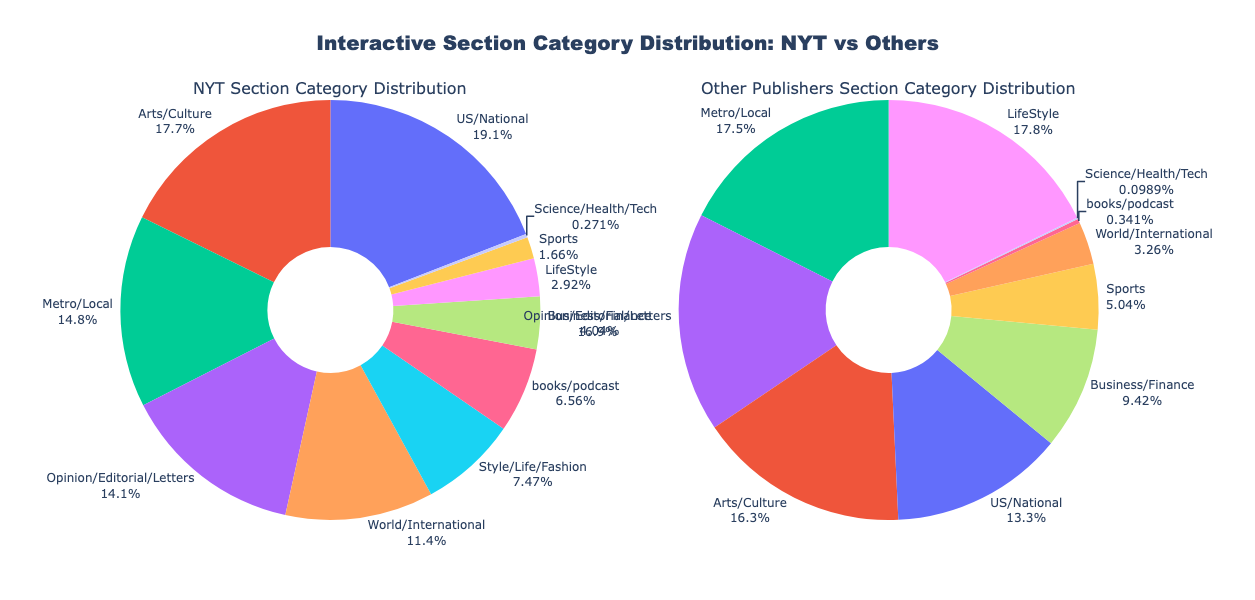

In [23]:
def interactive_pie_charts(df_articles, title="Section Category Distribution Comparison"):
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    import plotly.express as px
    
    # Compute counts for NYT vs Others based on 'section_category'
    nyt_data = df_articles[df_articles['publisher'] == 'New York Times']['section_category'].value_counts()
    other_data = df_articles[df_articles['publisher'] != 'New York Times']['section_category'].value_counts()
    
    # Create subplots
    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{"type": "pie"}, {"type": "pie"}]],
        subplot_titles=("NYT Section Category Distribution", "Other Publishers Section Category Distribution")
    )
    
    # NYT pie chart
    fig.add_trace(
        go.Pie(
            labels=nyt_data.index,
            values=nyt_data.values,
            name="NYT",
            hole=0.3,
            textinfo='label+percent',
            textposition='outside',
            textfont=dict(size=12),
            hovertemplate='<b>%{label}</b><br>' +
                         'Count: %{value}<br>' +
                         'Percentage: %{percent}<br>' +
                         '<extra></extra>',
            showlegend=False
        ),
        row=1, col=1
    )
    
    # Other publishers pie chart
    fig.add_trace(
        go.Pie(
            labels=other_data.index,
            values=other_data.values,
            name="Others",
            hole=0.3,
            textinfo='label+percent',
            textposition='outside',
            textfont=dict(size=12),
            hovertemplate='<b>%{label}</b><br>' +
                         'Count: %{value}<br>' +
                         'Percentage: %{percent}<br>' +
                         '<extra></extra>',
            showlegend=False
        ),
        row=1, col=2
    )
    
    # Layout styling
    fig.update_layout(
        title=dict(
            text=title,
            x=0.5,
            font=dict(size=20, family="Arial Black")
        ),
        width=1200,
        height=600,
        font=dict(size=12),
        showlegend=False
    )
    
    fig.show()

interactive_pie_charts(df_articles, "Interactive Section Category Distribution: NYT vs Others")


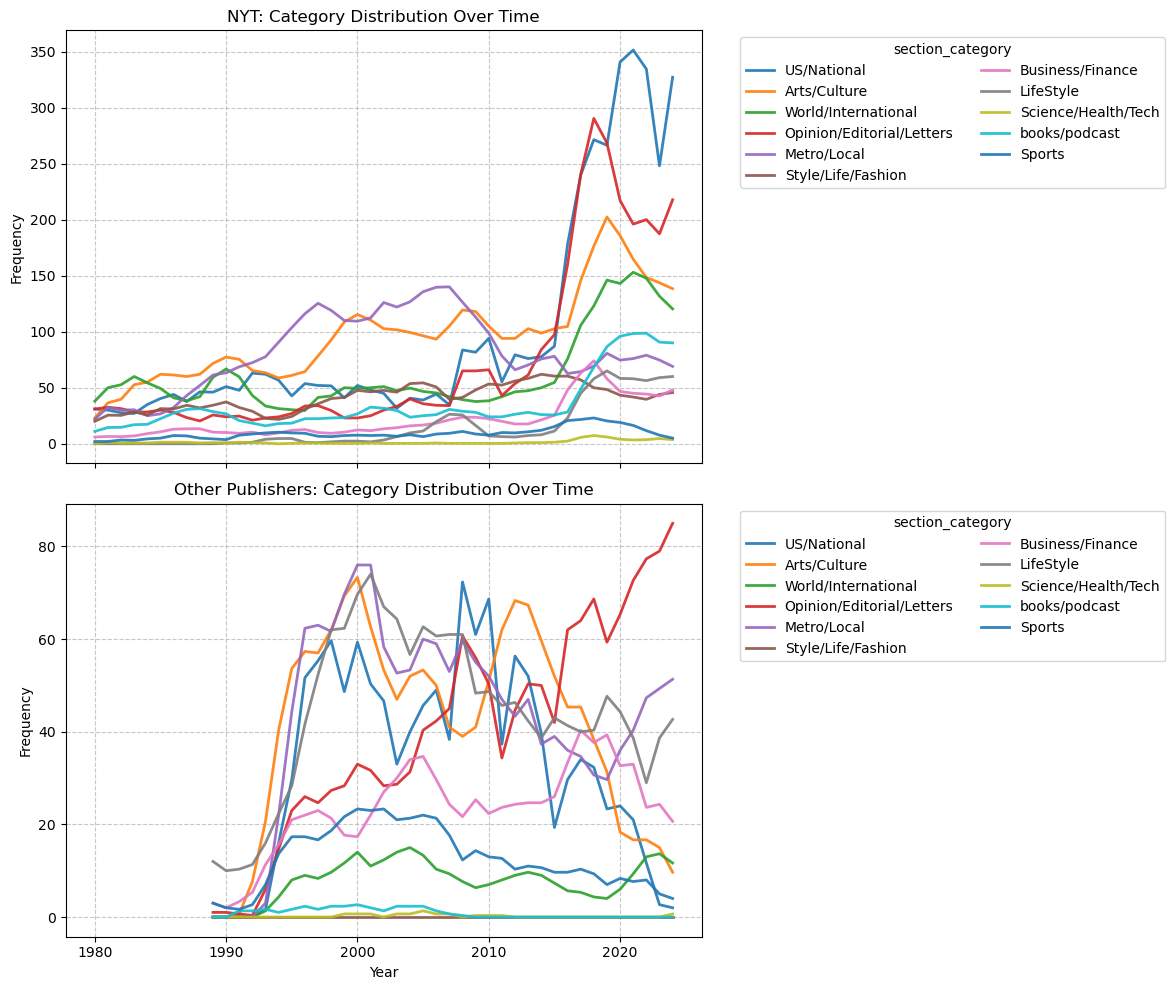

In [24]:
df_articles['year'] = pd.to_datetime(df_articles['date']).dt.year
nyt_mask = df_articles['publisher'] == 'New York Times'
line_time_plot(
    df_articles_with_results=df_articles,
    nyt_mask=nyt_mask,
    variable='section_category',
    title='Category Distribution Over Time',
    filename='category_distribution_over_time.png',
    variable_label='section_category',
    smooth_window=3
)

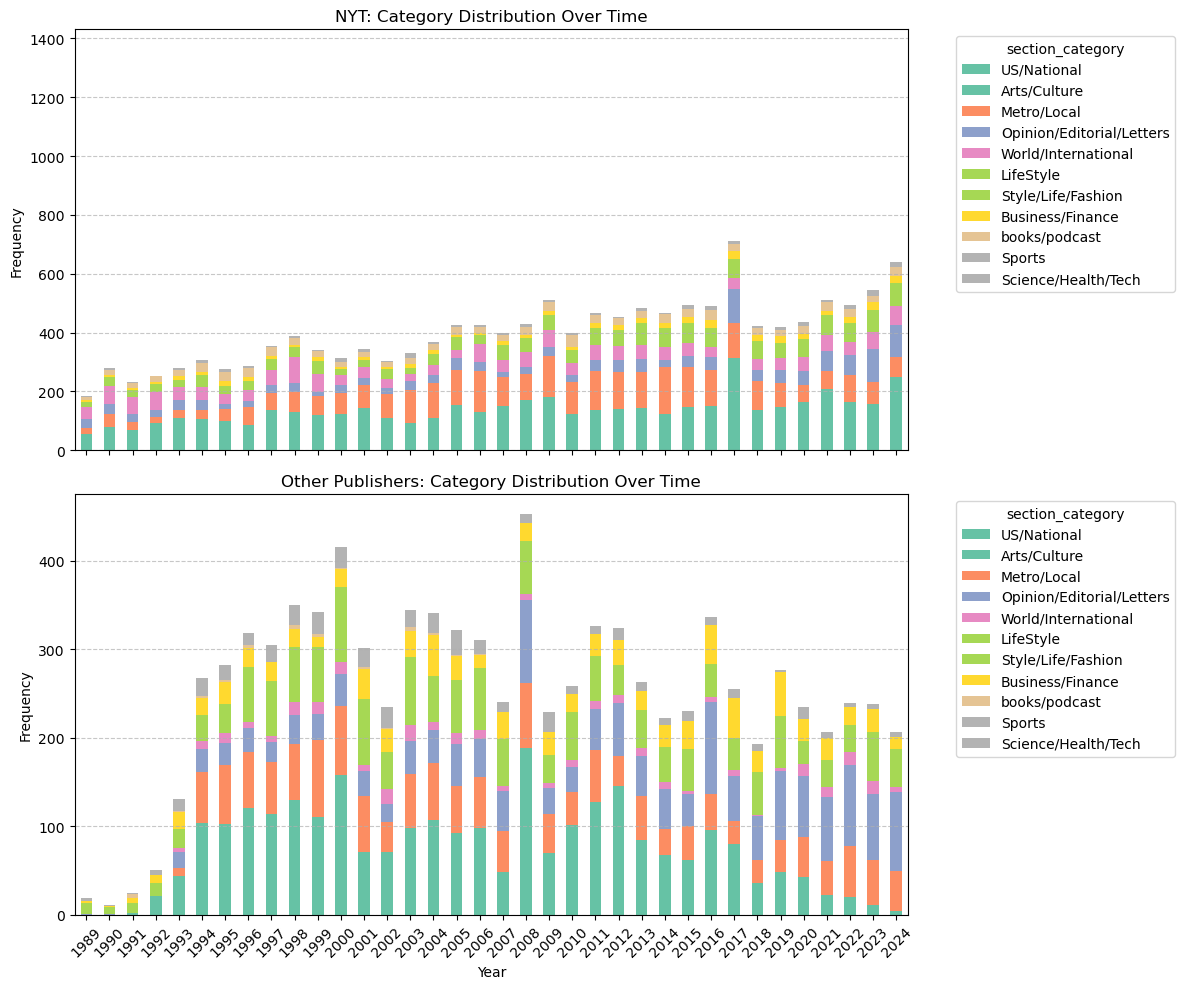

In [25]:
stacked_time_plot(
    df_articles_with_results=df_articles,
    nyt_mask=nyt_mask,
    variable='section_category',
    title='Category Distribution Over Time'
)

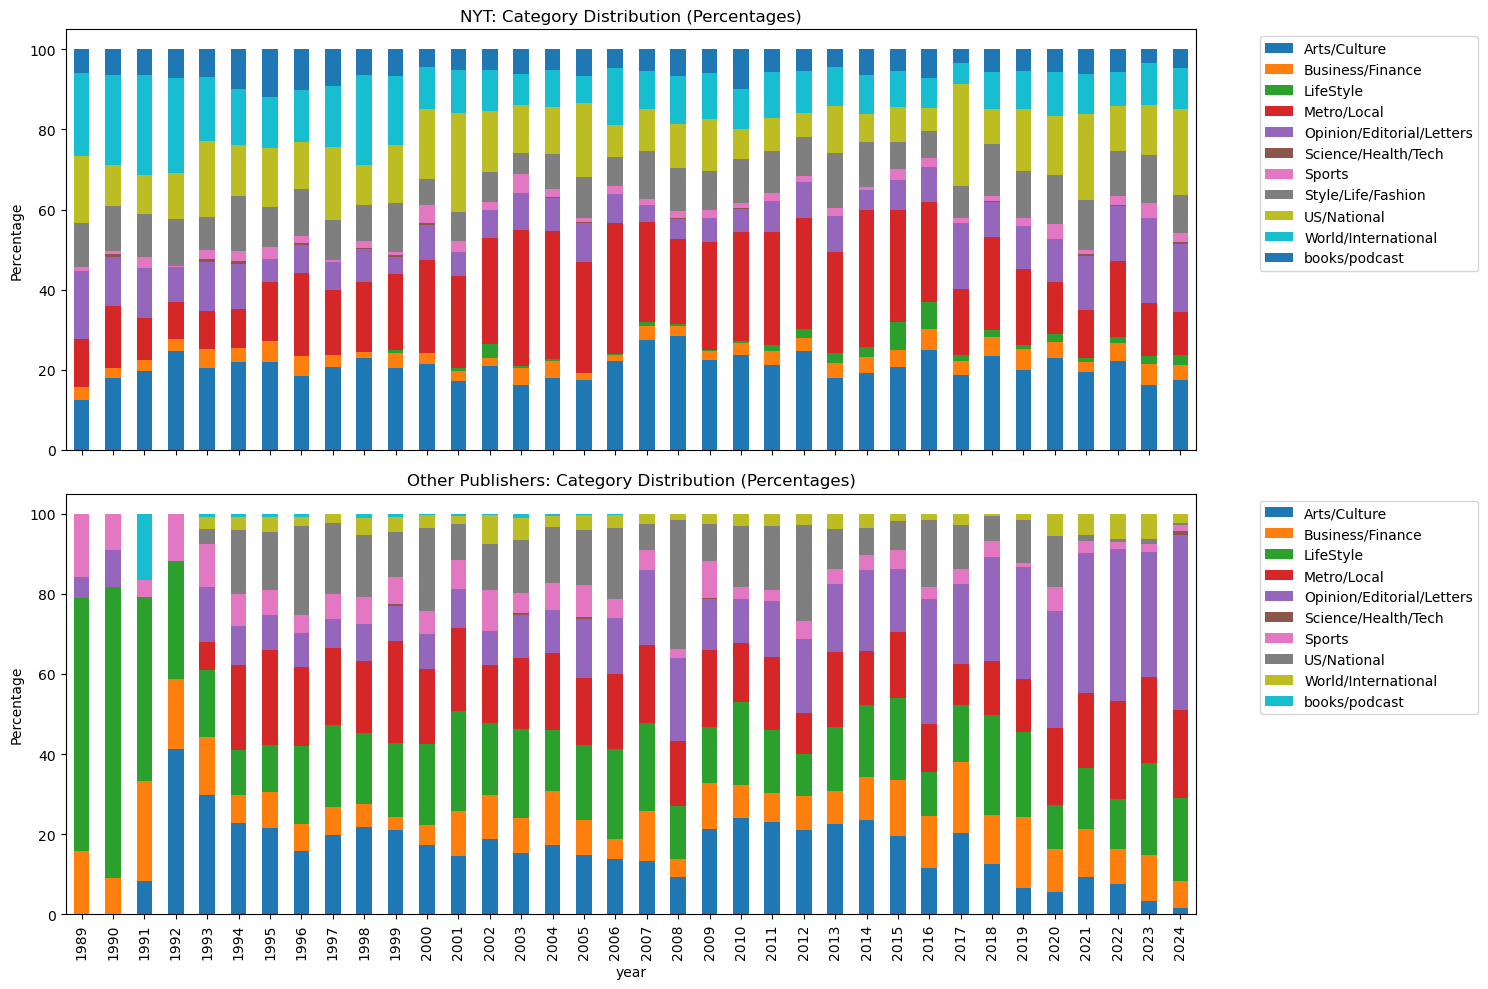

In [26]:
def proportional_stacked_plot(df, nyt_mask, variable, title):
    fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)  # Made figure wider
    
    for ax, mask, subtitle in zip(axes, [nyt_mask, ~nyt_mask], 
                                 [f"NYT: {title}", f"Other Publishers: {title}"]):
        grouped = df_articles[mask].groupby(["year", variable]).size().unstack(fill_value=0)
        grouped_pct = grouped.div(grouped.sum(axis=1), axis=0) * 100
        
        grouped_pct.plot(kind="bar", stacked=True, ax=ax)
        ax.set_ylabel("Percentage")
        ax.set_title(subtitle)
        
        # Move legend to the right side
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

df_articles['year'] = pd.to_datetime(df_articles['date']).dt.year
nyt_mask = df_articles['publisher'] == 'New York Times'
proportional_stacked_plot(df_articles, nyt_mask, 'section_category', 'Category Distribution (Percentages)')

In [27]:
unique_categories = df_articles['section_category'].unique()
print("Unique categories using .unique():")
print(unique_categories)

Unique categories using .unique():
['US/National' None 'Arts/Culture' 'World/International'
 'Opinion/Editorial/Letters' 'Metro/Local' 'Style/Life/Fashion'
 'Business/Finance' 'LifeStyle' 'Science/Health/Tech' 'books/podcast'
 'Sports']


In [ ]:
random_row = df_articlesf[df_articles['section_category'] == 'Arts/Culture'].sample(1)
article_index = random_row.index[0]

print(f"Article index: {article_index}")
print(f"Article body: {random_row['body'].iloc[0]}")

<a id="length_over_time"></a>
### Average Article Length Over Time

In [ ]:
print(f"\n{'-'*60}")
print("ARTICLE LENGTH ANALYSIS OVER TIME")
print(f"{'-'*60}")

df_length_analysis = df_articles[df_articles['word_count'] > 0].copy()
print(f"Articles with valid word counts: {len(df_length_analysis):,} ({100*len(df_length_analysis)/len(df_articles):.1f}%)")
print(f"Overall average article length: {df_length_analysis['word_count'].mean():.0f} words")
print(f"Median article length: {df_length_analysis['word_count'].median():.0f} words")
print(f"Length range: {df_length_analysis['word_count'].min()} - {df_length_analysis['word_count'].max():,} words")

# Calculate yearly statistics
yearly_avg_length = df_length_analysis.groupby('year')['word_count'].agg(['mean', 'median', 'std']).reset_index()

# Create visualizations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# ============================================================================
# 1. YEARLY TRENDS
# ============================================================================
ax1.plot(yearly_avg_length['year'], yearly_avg_length['mean'], 
         marker='o', linewidth=2, color='darkblue', label='Mean')
ax1.plot(yearly_avg_length['year'], yearly_avg_length['median'], 
         marker='s', linewidth=2, color='red', label='Median')
ax1.fill_between(yearly_avg_length['year'], 
                yearly_avg_length['mean'] - yearly_avg_length['std'],
                yearly_avg_length['mean'] + yearly_avg_length['std'],
                alpha=0.2, color='darkblue', label='±1 Std Dev')

ax1.set_title('Average Article Length Over Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average Word Count')
ax1.legend()
ax1.grid(alpha=0.3)

# ============================================================================
# 2. IMPROVED BOXPLOT BY DECADE
# ============================================================================
df_length_analysis['decade'] = (df_length_analysis['year'] // 10) * 10
decades = sorted(df_length_analysis['decade'].unique())

# Create boxplot with better styling and outlier handling
box_data = []
box_labels = []
decade_stats = []

for decade in decades:
    decade_data = df_length_analysis[df_length_analysis['decade'] == decade]['word_count']
    if len(decade_data) > 0:
        box_data.append(decade_data.values)
        box_labels.append(f"{decade}s")
        decade_stats.append({
            'decade': decade,
            'count': len(decade_data),
            'median': decade_data.median(),
            'mean': decade_data.mean()
        })

# Create boxplot with improved readability
bp = ax2.boxplot(box_data, labels=box_labels, patch_artist=True, 
                 showfliers=True,  # Show outliers but limit them
                 flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.5))

# Color the boxes with a gradient
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC']
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(colors[i % len(colors)])
    patch.set_alpha(0.7)

# Add mean markers
for i, stats in enumerate(decade_stats):
    ax2.plot(i+1, stats['mean'], marker='D', color='red', markersize=6, 
             label='Mean' if i == 0 else "")

ax2.set_title('Article Length Distribution by Decade', fontsize=14, fontweight='bold')
ax2.set_xlabel('Decade')
ax2.set_ylabel('Word Count')
ax2.grid(axis='y', alpha=0.3)
ax2.legend()

# Set y-axis limit to reduce impact of extreme outliers
ax2.set_ylim(0, np.percentile([item for sublist in box_data for item in sublist], 95) * 1.2)

plt.tight_layout()
plt.show()

# Print decade statistics
print(f"\nDecade-by-decade breakdown:")
for stats in decade_stats:
    print(f"  {stats['decade']}s: {stats['count']:,} articles, "
          f"median = {stats['median']:.0f} words, mean = {stats['mean']:.0f} words")

# ============================================================================
# 3. PUBLISHER COMPARISON (Updated for two publishers)
# ============================================================================
plt.figure(figsize=(12, 6))

publishers = ['New York Times', 'Other publisher']
colors = ['steelblue', 'darkred']

for i, publisher in enumerate(publishers):
    publisher_data = df_length_analysis[df_length_analysis['publisher'] == publisher]
    if len(publisher_data) > 0:
        yearly_pub_length = publisher_data.groupby('year')['word_count'].mean()
        plt.plot(yearly_pub_length.index, yearly_pub_length.values, 
                marker='o', linewidth=3, label=f'{publisher} ({len(publisher_data):,} articles)', 
                color=colors[i])

plt.title('Average Article Length Trends by Publisher', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Word Count')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics by publisher
print(f"\nLength comparison by publisher:")
for publisher in publishers:
    pub_data = df_length_analysis[df_length_analysis['publisher'] == publisher]
    if len(pub_data) > 0:
        print(f"  {publisher}: {pub_data['word_count'].mean():.0f} words average, "
              f"{pub_data['word_count'].median():.0f} words median ({len(pub_data):,} articles)")